## Policy Iteration using KotlinRL Maze Env

In [1]:
USE {
    repositories {
        mavenCentral()
        maven("https://central.sonatype.com/repository/maven-snapshots/")
    }
    dependencies {
        implementation("io.github.kotlinrl:envs:0.1.0-SNAPSHOT")
    }
}
%use dataframe
%use kandy

In [2]:
import io.github.kotlinrl.core.*
import io.github.kotlinrl.envs.*

Let's set up our testing parameters.  There is no training with value iteration.  The ```Value Iteration Algorithm``` works against a Model Based Environment to calculate the best ```Policy``` for the agent.

In [3]:
val testEpisodes = 3
val stateActionListProvider = StateActionListProvider<IntArray, Int> { listOf(0, 1, 2, 3) }
val stateShape = intArrayOf(5, 5)
val pTable = PTable(*stateShape)
val vTable = VTable(*stateShape)

In [ ]:
val env = Maze(render = true)
val testingAgent = agent(
    id = "testing",
    policy = policyIteration(
        env = env,
        pTable = pTable,
        vTable = vTable,
        stateActionListProvider = stateActionListProvider
    ),
)
println("Testing agent:")
val recordEnv = RecordVideo(env, folder = "videos/maze_policy_iteration")
val trainer = episodicTrainer(
    agent = testingAgent,
    env = recordEnv,
)
val testResults = trainer.train(testEpisodes)
println("Test results: ${testResults.episodeRewards}")
repeat(testEpisodes) {
    displayVideo(
        episode = it + 1,
        folder = recordEnv.folder,
    )
}


In [5]:
val actionSymbols = mapOf(0 to "↑", 1 to "→", 2 to "↓", 3 to "←")
val shape = vTable.shape

val stateDf = buildList {
    for (row in 0 until shape[0]) {
        for (col in 0 until shape[1]) {
            val state = intArrayOf(row, col)
            val value = (vTable[state] * 100).roundToInt() / 100.0
            val action = pTable[state]
            val arrow = actionSymbols[action] ?: "?"

            // Two rows per cell: one for value, one for arrow
            add(mapOf("x" to col, "y" to -row, "value" to value, "label" to "$value", "type" to "Value"))
            add(mapOf("x" to col, "y" to -row, "value" to value, "label" to arrow, "type" to "Policy"))
        }
    }
}.flatMap { it.entries }.groupBy({ it.key}, { it.value }).toDataFrame()

plotGrid(stateDf.groupBy("type").map { (typeLabel, group) ->
    group.plot {
        layout.title = typeLabel[0]?.toString() ?: ""

        tiles {
            x("x")
            y("y")
            fillColor("value") {
                scale = continuous(Color.WHITE..Color.BLUE)
            }
            borderLine {
                width = 0.5
                color = Color.BLACK
            }
        }


        text {
            x("x")
            y("y")
            label("label")
            font {
                size = if (typeLabel[0] == "Policy") 18.0 else 6.0
                color = Color.BLACK
            }
        }

        x.axis.name = "x"
        y.axis.name = "y"
    }
})

<head>
 <meta charset="UTF-8">
 <style> html, body { margin: 0; overflow: hidden; } </style>
 <script type="text/javascript" data-lets-plot-script="library" src="https://cdn.jsdelivr.net/gh/JetBrains/lets-plot@v4.5.1/js-package/distr/lets-plot.min.js"></script>
 </head>
 <body>
 <div id="ZlssfE"></div>
 <script type="text/javascript" data-lets-plot-script="plot">
 
 (function() {
 // ----------
 
 var plotSpec={
"layout":{
"name":"grid",
"ncol":2,
"nrow":1,
"fit":true,
"align":false
},
"figures":[{
"ggtitle":{
"text":"Value"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0],
"y":[0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,-4.0,-4.0,-4.0,-4.0],
"label":["-8.65","-9.56","-10.47","-11.36","-12.25","-7.73","-10.47","-14.85","-12.25","-13.13","-6.79","-11.36","-13.99","-13.13","-13.99","-5.85","-12.25","-1.99","-1.0","0.0","-4.9","-3.94","-2.97","0.0","0.0"],
"value":[-8.65,-9.56,-10.47,-11.36,-12.25,-7.73,-10.47,-14.85,-12.25,-13.13,-6.79,-11.36,-13.99,-13.13,-13.99,-5.85,-12.25,-1.99,-1.0,0.0,-4.9,-3.94,-2.97,0.0,0.0]
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#5470c6",
"low":"#ffffff",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"label"
},
"stat":"identity",
"size":6.0,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"text",
"data":{
}
}],
"data_meta":{
"series_annotations":[{
"type":"int",
"column":"x"
},{
"type":"int",
"column":"y"
},{
"type":"float",
"column":"value"
},{
"type":"str",
"column":"label"
}]
},
"spec_id":"3"
},{
"ggtitle":{
"text":"Policy"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0],
"y":[0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,-4.0,-4.0,-4.0,-4.0],
"label":["↓","←","←","←","←","↓","↑","↓","↑","↑","↓","↑","→","↑","↑","↓","↑","→","→","↓","→","→","↑","→","→"],
"value":[-8.65,-9.56,-10.47,-11.36,-12.25,-7.73,-10.47,-14.85,-12.25,-13.13,-6.79,-11.36,-13.99,-13.13,-13.99,-5.85,-12.25,-1.99,-1.0,0.0,-4.9,-3.94,-2.97,0.0,0.0]
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#5470c6",
"low":"#ffffff",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"label"
},
"stat":"identity",
"size":18.0,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"text",
"data":{
}
}],
"data_meta":{
"series_annotations":[{
"type":"int",
"column":"x"
},{
"type":"int",
"column":"y"
},{
"type":"float",
"column":"value"
},{
"type":"str",
"column":"label"
}]
},
"spec_id":"4"
}],
"kind":"subplots"
};
 var containerDiv = document.getElementById("ZlssfE");
 
 var toolbar = null;
 var plotContainer = containerDiv; 
 
 var options = {
 sizing: {
 width_mode: "fixed",
 height_mode: "fixed",
 width: 600.0,
 height: 400.0
 }

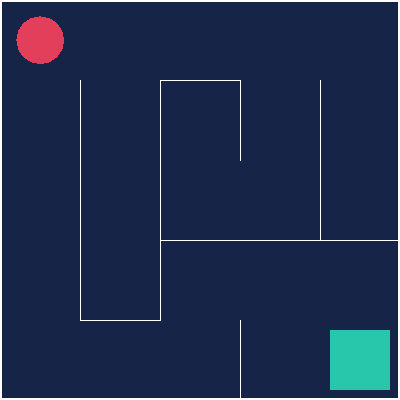

In [6]:
import java.io.File
import javax.imageio.ImageIO
import java.awt.image.BufferedImage

val pngFile = File(recordEnv.folder).listFiles()?.sorted()?.first()?.listFiles()?.sorted()?.first()

val image: BufferedImage = ImageIO.read(pngFile)
image